In [1]:
import sys 
import xarray as xr
import numpy as np
import os
import pandas as pd
import yaml
from numpy import random
import math
from datetime import datetime, timedelta
from parcels import FieldSet, Field, VectorField, ParticleSet, JITParticle, ParcelsRandom, Variable
from glob import glob

In [2]:
sys.path.append(os.getcwd()+'/Source')

from OP_Kernels import *
from OP_functions import *

In [3]:
def load_config(config_yaml):
   with open(config_yaml) as f:
       config = yaml.safe_load(f)
   return config

In [4]:
(1773804849.0278132-1773804677.8632925)/2

85.58226037025452

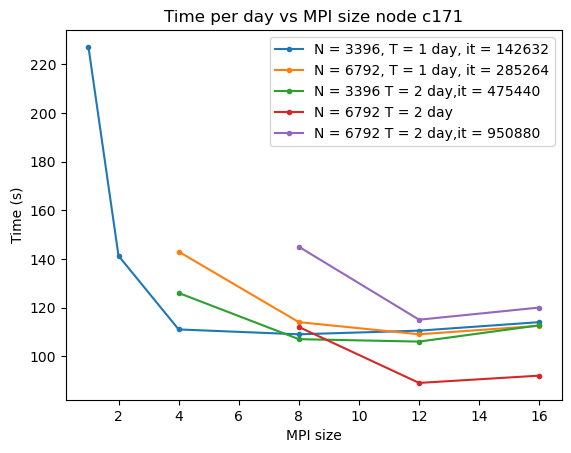

In [5]:
import matplotlib.pyplot as plt
#simple_partition 1day 3396 particles
mpi_size = [1,2,4,8,12,16]
time_run = [227.2,141.3,111,109,110.5,114]
time_run2 = [143,114,109,112.5]
time_run3 = [126,107,106,112.7]
time_run4 = [112,89,92]
time_run5 = [145,115,120] #Conversion basada en volver a correr run3 (nueva sesion mas rapida)

plt.plot(mpi_size,time_run,'.-',label='N = 3396, T = 1 day, it = 142632')
plt.plot(mpi_size[2:],time_run2,'.-',label='N = 6792, T = 1 day, it = 285264')
plt.plot(mpi_size[2:],time_run3,'.-',label='N = 3396 T = 2 day,it = 475440')
plt.plot(mpi_size[3:],time_run4,'.-',label='N = 6792 T = 2 day')
plt.plot(mpi_size[3:],time_run5,'.-',label='N = 6792 T = 2 day,it = 950880')


plt.xlabel('MPI size')
plt.ylabel('Time (s)')
plt.title('Time per day vs MPI size node c171')
plt.legend()

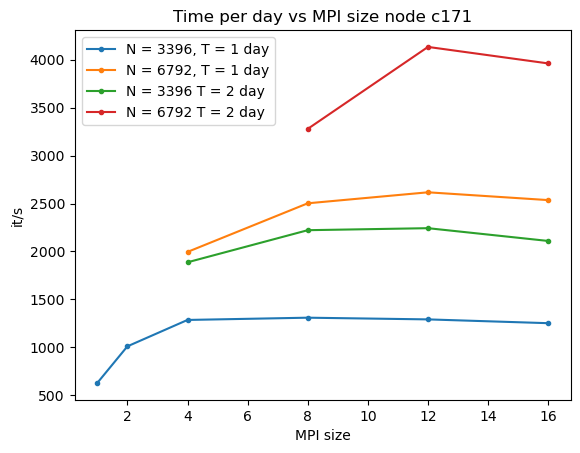

In [66]:
import matplotlib.pyplot as plt
import numpy as np
mpi_size = [1,2,4,8,12,16]
time_run = [227.2,141.3,111,109,110.5,114]
time_run2 = [143,114,109,112.5]
time_run3 = [126,107,106,112.7]
time_run5 = [145,115,120] #Conversion basada en volver a correr run3 (nueva sesion mas rapida)

plt.plot(mpi_size,142632/np.array(time_run),'.-',label='N = 3396, T = 1 day')
plt.plot(mpi_size[2:],285264/np.array(time_run2),'.-',label='N = 6792, T = 1 day')
plt.plot(mpi_size[2:],237720/np.array(time_run3),'.-',label='N = 3396 T = 2 day')
plt.plot(mpi_size[3:],475440/np.array(time_run5),'.-',label='N = 6792 T = 2 day')


plt.xlabel('MPI size')
plt.ylabel('it/s')
plt.title('Time per day vs MPI size node c171')
plt.legend()

In [53]:
param = load_config('yaml/config.yaml')
start = datetime(param['startdate']['year'], param['startdate']['month'], param['startdate']['day']) #Start date
length = param['param']['length'] # Set Time length [days] 
dt = param['param']['dt'] #toggle between - or + to pick backwards or forwards 
N = param['param']['N'] # Name of deploy loc file
dd = param['param']['dd'] #max depth difference z in N
name = param['file']['name'] #name output file
dtp = param['param']['dtp'] #how often particle released in hours
odt = param['param']['odt'] #how often data is recorded
rrr = param['param']['r'] #radious of particle deployment
SI = param['param']['SI'] #how many particles per super-individual

duration = timedelta(days=length)
print(f"The model will run for {duration.days} days, starting at {start}")

lon, lat, z = pandas_deploy(N,SI,rrr,dd,dtp)
N = len(lat)
print(f"The model will release {N} particle every timestep")

daterange = [start+timedelta(days=i) for i in range(length)]
fn =  name + '.zarr'
outfile = os.path.join(os.getcwd()+'/results/', fn)

print(f"Output file: {outfile}")

The model will run for 5 days, starting at 2007-04-01 00:00:00
The model will release 3396 particle every timestep
Output file: /home/jvalenti/MOAD/analysis-jose/notebooks/MP_model/results/test_reseed.zarr


In [54]:
chunksize_fields = {
    "lon": ("lon", 66),   # matches 1 MPI box in lon
    "lat": ("lat", 28),   # matches 1 MPI box in lat
    "time": ("time", 1)
}

In [55]:
####BUILD FIELDS FOR SIMULATION######
#Fill in the list of variables that you want to use as fields
varlist=['U','V','W']
filenames,variables=filename_set(start,length,varlist)
dimensions = {'lon': 'glamf', 'lat': 'gphif', 'depth': 'depthw','time': 'time_counter'}
field_set=FieldSet.from_nemo(filenames, variables, dimensions, allow_time_extrapolation=True)

#Find file names and variable names ###'Diat','Flag'###
varlist=['US','VS','WL','R','T','S','ssh','Bathy','Kz','totdepth']
filenames,variables=filename_set(start,length,varlist)

# #Add Stokes Drift fields
# dimensions = {'lon': 'longitude', 'lat': 'latitude', 'time': 'time'}
# us = Field.from_netcdf(filenames['US'], variables['US'], dimensions,allow_time_extrapolation=True)
# vs = Field.from_netcdf(filenames['VS'], variables['VS'], dimensions,allow_time_extrapolation=True)
# wl = Field.from_netcdf(filenames['WL'], variables['WL'], dimensions,allow_time_extrapolation=True)
# field_set.add_field(us)
# field_set.add_field(vs)
# field_set.add_field(wl)
# field_set.add_vector_field(VectorField("stokes", us, vs, wl))

#Add Vertical diffusivity coefficient field
dimensions = {'lon': 'glamt', 'lat': 'gphit', 'depth': 'depthw','time': 'time_counter'}
Kz = Field.from_netcdf(filenames['Kz'], variables['Kz'], dimensions,allow_time_extrapolation=True)
field_set.add_field(Kz)

#Add fields located at node T
dimensions = {'lon': 'glamt', 'lat': 'gphit', 'depth': 'deptht','time': 'time_counter'}

R = Field.from_netcdf(filenames['R'], variables['R'], dimensions,allow_time_extrapolation=True)
S = Field.from_netcdf(filenames['S'], variables['S'], dimensions,allow_time_extrapolation=True)
T = Field.from_netcdf(filenames['T'], variables['T'], dimensions,allow_time_extrapolation=True)
field_set.add_field(R)
field_set.add_field(S)
field_set.add_field(T)

#Add Bathymetry 2D field
dimensions = {'lon': 'glamt', 'lat': 'gphit'}
Bth = Field.from_netcdf(filenames['Bathy'], variables['Bathy'], dimensions,allow_time_extrapolation=True)
TD = Field.from_netcdf(filenames['totdepth'], variables['totdepth'], dimensions,allow_time_extrapolation=True)
field_set.add_field(Bth)
field_set.add_field(TD)

#Add SSH 
dimensions = {'lon': 'glamt', 'lat': 'gphit','time': 'time_counter'}
SSH = Field.from_netcdf(filenames['ssh'], variables['ssh'], dimensions,allow_time_extrapolation=True)
field_set.add_field(SSH)

/project/def-allen/SalishSea/nowcast-green.202111/01apr07/SalishSea_1h_20070401_20070401
/project/def-allen/SalishSea/nowcast-green.202111/02apr07/SalishSea_1h_20070402_20070402
/project/def-allen/SalishSea/nowcast-green.202111/03apr07/SalishSea_1h_20070403_20070403
/project/def-allen/SalishSea/nowcast-green.202111/04apr07/SalishSea_1h_20070404_20070404
/project/def-allen/SalishSea/nowcast-green.202111/05apr07/SalishSea_1h_20070405_20070405


/home/jvalenti/miniforge3/envs/Parcels_26/lib/python3.11/site-packages/parcels/field.py:648: FileWarning: File /home/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc could not be decoded properly by xarray (version 2024.6.0). It will be opened with no decoding. Filling values might be wrongly parsed.
  with _grid_fb_class(
/home/jvalenti/miniforge3/envs/Parcels_26/lib/python3.11/site-packages/parcels/field.py:648: FileWarning: File /home/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc could not be decoded properly by xarray (version 2024.6.0). It will be opened with no decoding. Filling values might be wrongly parsed.
  with _grid_fb_class(
/home/jvalenti/miniforge3/envs/Parcels_26/lib/python3.11/site-packages/parcels/field.py:648: FileWarning: File /home/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc could not be decoded properly by xarray (version 2024.6.0). It will be opened with no decoding. Filling values might be wrongly parsed.
  with _grid_fb_class

/project/def-allen/SalishSea/nowcast-green.202111/01apr07/SalishSea_1h_20070401_20070401
/project/def-allen/SalishSea/nowcast-green.202111/02apr07/SalishSea_1h_20070402_20070402
/project/def-allen/SalishSea/nowcast-green.202111/03apr07/SalishSea_1h_20070403_20070403
/project/def-allen/SalishSea/nowcast-green.202111/04apr07/SalishSea_1h_20070404_20070404
/project/def-allen/SalishSea/nowcast-green.202111/05apr07/SalishSea_1h_20070405_20070405


/home/jvalenti/miniforge3/envs/Parcels_26/lib/python3.11/site-packages/parcels/field.py:648: FileWarning: File /home/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc could not be decoded properly by xarray (version 2024.6.0). It will be opened with no decoding. Filling values might be wrongly parsed.
  with _grid_fb_class(
/home/jvalenti/miniforge3/envs/Parcels_26/lib/python3.11/site-packages/parcels/field.py:648: FileWarning: File /home/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc could not be decoded properly by xarray (version 2024.6.0). It will be opened with no decoding. Filling values might be wrongly parsed.
  with _grid_fb_class(
/home/jvalenti/miniforge3/envs/Parcels_26/lib/python3.11/site-packages/parcels/field.py:648: FileWarning: File /home/jvalenti/MOAD/grid/coordinates_seagrid_SalishSea201702.nc could not be decoded properly by xarray (version 2024.6.0). It will be opened with no decoding. Filling values might be wrongly parsed.
  with _grid_fb_class

In [18]:
#MPI decomposition
Px = 6  # number of boxes along x (longitude)
Py = 32   # number of boxes along y (latitude)
mpi_size = Px * Py  # should equal 192 NIBI

# Set domain bounds from the model grid
xmin = field_set.U.grid.lon.min()
xmax = field_set.U.grid.lon.max()
ymin = field_set.U.grid.lat.min()
ymax = field_set.U.grid.lat.max()

x_edges = np.linspace(xmin, xmax, Px + 1)
y_edges = np.linspace(ymin, ymax, Py + 1)

def nemo_partition_function(pset, mpi_size): 
    """Custom partition function for Parcels similar to NEMO MPI decomposition.
    Returns an array of processor IDs for each particle."""
    
    lon = pset.lon
    lat = pset.lat

    # Find which box each particle belongs to
    ix = np.searchsorted(x_edges, lon) - 1
    iy = np.searchsorted(y_edges, lat) - 1

    # Clamp indices to valid range
    ix = np.clip(ix, 0, Px - 1)
    iy = np.clip(iy, 0, Py - 1)

    # Map 2D box index to processor ID
    proc_id = iy * Px + ix

    return proc_id

In [14]:
#Define our Parcels Particles
class MPParticle(JITParticle):    
    diameter = Variable('diameter', initial = param['particle']['diameter'])
    length = Variable('length', initial = param['particle']['length'])
    Ub = Variable('Ub', initial = param['particle']['Ub'])  
    status = Variable('status', initial = 0)
    vvl_factor = Variable('fact', initial =  1)    
    ws = Variable('ws', initial =  0) 
    wa = Variable('wa', initial =  0) 
    wm = Variable('wm', initial =  0) 
    alpha = Variable('alpha',initial=param['particle']['alpha'])

In [20]:
pset = ParticleSet.from_list(field_set, MPParticle, lon=lon, lat=lat, depth=z, repeatdt = timedelta(hours=dtp),partition_function=nemo_partition_function)

In [17]:
pset.execute([Advection,Buoyancy,turb_mix,Displacement,export,CheckOutOfBounds,KeepInOcean],
        runtime=duration, 
        dt=dt,
        output_file=pset.ParticleFile(name=outfile, outputdt=timedelta(hours=odt),chunks=(int(1e5), 100)))

INFO: Output files are stored in /home/jvalenti/MOAD/analysis-jose/notebooks/MP_model/results/test_reseed.zarr.
  0%|          | 0/172800.0 [00:00<?, ?it/s]

/home/jvalenti/miniforge3/envs/Parcels_26/lib/python3.11/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 128. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/home/jvalenti/miniforge3/envs/Parcels_26/lib/python3.11/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 128. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/home/jvalenti/miniforge3/envs/Parcels_26/lib/python3.11/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 128. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/home/jvalenti/miniforge3/envs/Parcels_26/lib/python3.11/site-packages/xarray/core/dataset.py:274: UserWarning: 

KeyboardInterrupt: 